# 실습 3-1 : Random Forest

#### **<실습 내용>**

1. 실습 데이터 탐색 및 전처리
- 분류 데이터 (MachineFailure)
- 회귀 데이터 (Concrete)

2. Random Forest Classifier
- 모델 학습 및 성능 평가
- 변수 중요도 시각화

3. Random Forest Regressor
- 모델 학습 및 성능 평가
- 변수 중요도 시각화

4. 하이퍼 파라미터 최적화
- GridSearchCV를 활용한 최적 파라미터 탐색

## 분석 준비

### 주요 라이브러리 호출

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

---

## 1) 분류 문제

In [2]:
MF_Data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day3-1_cls_data.csv"))
MF_Data.head()

,Temperature,Humidity,Operator,Measure1,Measure2,Measure3,Measure4,Measure5,Measure6,Measure7,Measure8,Measure9,Measure10,Measure11,Measure12,Measure13,Measure14,Measure15,Hours Since Previous Failure,Failure
0,67,82,Operator1,291,1,1,1041,846,334,706,1086,256,1295,766,968,1185,1355,1842,90,No
1,68,77,Operator1,1180,1,1,1915,1194,637,1093,524,919,245,403,723,1446,719,748,91,No
2,64,76,Operator1,1406,1,1,511,1577,1121,1948,1882,1301,273,1927,1123,717,1518,1689,92,No
3,63,80,Operator1,550,1,1,1754,1834,1413,1151,945,1312,1494,1755,1434,502,1336,711,93,No
4,65,81,Operator1,1928,1,2,1326,1082,233,1441,1736,1033,1549,802,1819,1616,1507,507,94,No


In [3]:
print("데이터 크기 :", MF_Data.shape)
print("출력변수 분포:")
print(MF_Data["Failure"].value_counts())

데이터 크기 : (7900, 20)
출력변수 분포:
Failure
No     7825
Yes      75
Name: count, dtype: int64


In [23]:
# 입출력 변수 분할
Y_cls = MF_Data["Failure"]
X_cls = MF_Data.drop(["Failure"], axis=1)

# 범주형 변수 처리
X_cls["Measure2"] = X_cls["Measure2"].astype("category")
X_cls["Measure3"] = X_cls["Measure3"].astype("category")
X_cls = pd.get_dummies(X_cls)
cls_columns = X_cls.columns

# 출력변수 인코딩
Y_cls = Y_cls.replace({"No": 0, "Yes": 1}).astype(int)

# 데이터 분할 (전체 변수)
X_train_cls, X_test_cls, Y_train_cls, Y_test_cls = train_test_split(
    X_cls, Y_cls, test_size=0.3, random_state=0, stratify=Y_cls)

print("학습 데이터 :", X_train_cls.shape)
print("테스트 데이터 :", X_test_cls.shape)

학습 데이터 : (5530, 31)
테스트 데이터 : (2370, 31)


In [25]:
# 분류 성능 평가 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred))
    print("Recall    : %.3f" % recall_score(real, pred))
    print("F1-score  : %.3f" % f1_score(real, pred))
    print()
    print("혼동행렬")
    print(confusion_matrix(real, pred))

---

### 1-1) Random Forest Classifier 모델 학습 및 성능 평가

> **Random Forest**는 Bagging의 일종으로, 붓스트랩 샘플링 + 무작위 변수 선택을 통해 다수의 의사결정나무를 생성하고 결합하는 앙상블 모델임
> - **붓스트랩 샘플링**: 학습 데이터에서 복원 추출로 여러 표본을 만들어 베이스 모델의 다양성을 확보함
> - **무작위 변수 선택**: 각 노드마다 입력변수의 일부만 랜덤 선택하여 트리 간 상관성을 줄임
> - 분류: 다수결 투표, 회귀: 평균으로 최종 예측을 수행함

In [10]:
print(Y_train_cls.dtype)   # int64 여야 함
print(Y_train_cls.unique())  # [0 1]

int64
[0 1]


In [11]:
RF_cls = RandomForestClassifier()
RF_cls.fit(X_train_cls, Y_train_cls)
RF_cls_pred = RF_cls.predict(X_test_cls)
get_classscore(Y_test_cls, RF_cls_pred)

Accuracy  : 0.997
Precision : 1.000
Recall    : 0.682
F1-score  : 0.811

혼동행렬
[[2348    0]
 [   7   15]]


### 1-2) 변수 중요도 시각화

> Random Forest는 **Mean Decrease in Impurity** 방식으로 변수 중요도를 산출함

> 각 트리에서 특정 변수가 노드 분할에 사용될 때의 불순도 감소량을 평균내어 중요도를 계산함

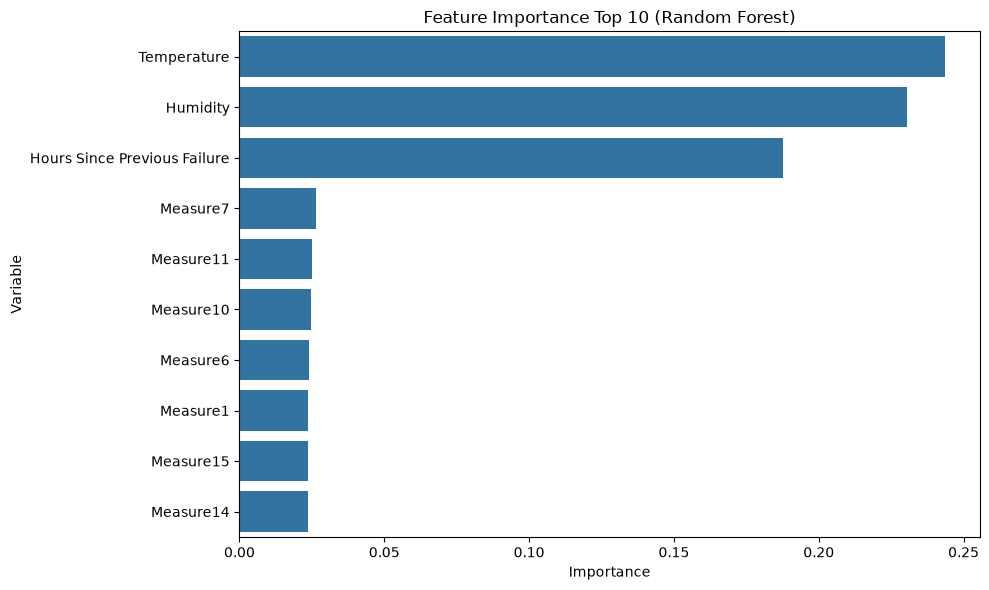

In [12]:
# 변수 중요도 추출 및 시각화
var_imp = pd.DataFrame({"Variable": cls_columns, "Importance": RF_cls.feature_importances_})
imp_top10 = var_imp.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=imp_top10)
plt.title("Feature Importance Top 10 (Random Forest)")
plt.tight_layout()
plt.show()

### 1-3) 모델 성능 개선

> Random Forest의 주요 하이퍼 파라미터:
>
> | 파라미터 | 의미 |
> |:---:|:---:|
> | n_estimators | 베이스 모델(의사결정나무)의 수 |
> | max_depth | 개별 트리의 최대 깊이 |
> | max_features | 각 노드에서 랜덤 선택하는 변수 수 (분류: sqrt, 회귀: n/3) |
> | min_samples_leaf | 끝 노드의 최소 샘플 수 |
> | min_samples_split | 노드 분할을 위한 최소 샘플 수 |

In [13]:
params = {
    "max_depth": [3, 5, 7],
    "min_samples_leaf": [2, 4, 8],
    "n_estimators": [100, 300],
    "max_features": ["sqrt", 3]
}

grid_cls = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid=params, cv=5, scoring="f1", n_jobs=-1
)
grid_cls.fit(X_train_cls, Y_train_cls)

print("최적 파라미터:", grid_cls.best_params_)
print("최적 F1-score: %.4f" % grid_cls.best_score_)

최적 파라미터: {'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 300}
최적 F1-score: 0.8058


In [14]:
# 최적 모델로 테스트 성능 평가
best_pred_cls = grid_cls.predict(X_test_cls)
get_classscore(Y_test_cls, best_pred_cls)

Accuracy  : 0.997
Precision : 1.000
Recall    : 0.727
F1-score  : 0.842

혼동행렬
[[2348    0]
 [   6   16]]


---

## 2) 회귀 문제

In [15]:
Concrete = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day3-1_reg_data.csv"))

Y_reg = Concrete["Concrete_compressive_strength"]
X_reg = Concrete.drop(["Concrete_compressive_strength"], axis=1)

X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(
    X_reg, Y_reg, test_size=0.3, random_state=0)

print("학습 데이터 :", X_train_reg.shape)
print("테스트 데이터 :", X_test_reg.shape)

학습 데이터 : (721, 8)
테스트 데이터 : (309, 8)


In [16]:
# 회귀 성능 평가 함수
def get_regscore(true, pred):
    print("MSE       : %.3f" % mean_squared_error(true, pred))
    print("RMSE      : %.3f" % np.sqrt(mean_squared_error(true, pred)))
    print("MAE       : %.3f" % mean_absolute_error(true, pred))
    print("R-squared : %.3f" % r2_score(true, pred))

### 2-1) Random Forest Regressor 모델 학습 및 성능 평가

In [17]:
RF_reg = RandomForestRegressor()
RF_reg.fit(X_train_reg, Y_train_reg)
RF_reg_pred = RF_reg.predict(X_test_reg)
get_regscore(Y_test_reg, RF_reg_pred)

MSE       : 26.346
RMSE      : 5.133
MAE       : 3.568
R-squared : 0.897


### 2-2) 변수 중요도 시각화

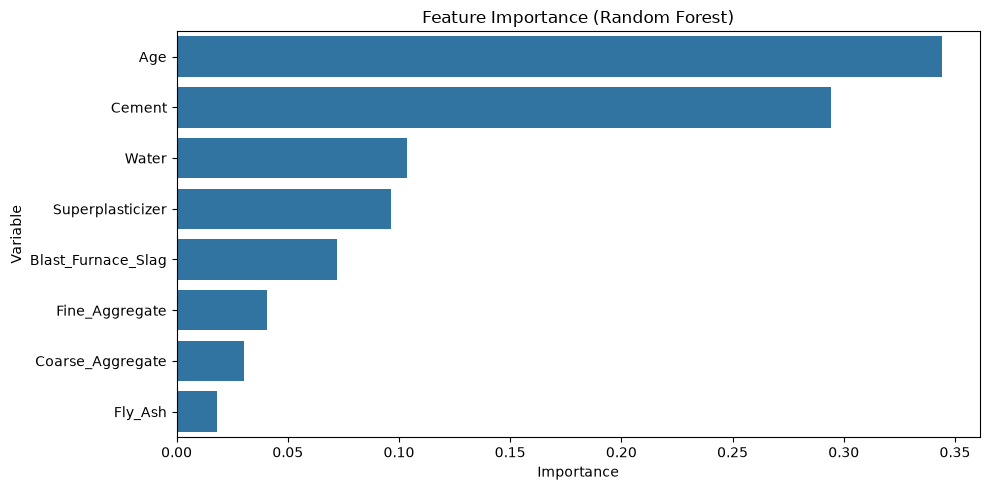

In [18]:
var_imp_reg = pd.DataFrame({"Variable": X_train_reg.columns, "Importance": RF_reg.feature_importances_})
var_imp_reg = var_imp_reg.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Variable", data=var_imp_reg)
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

### 2-3) 예측 시각화

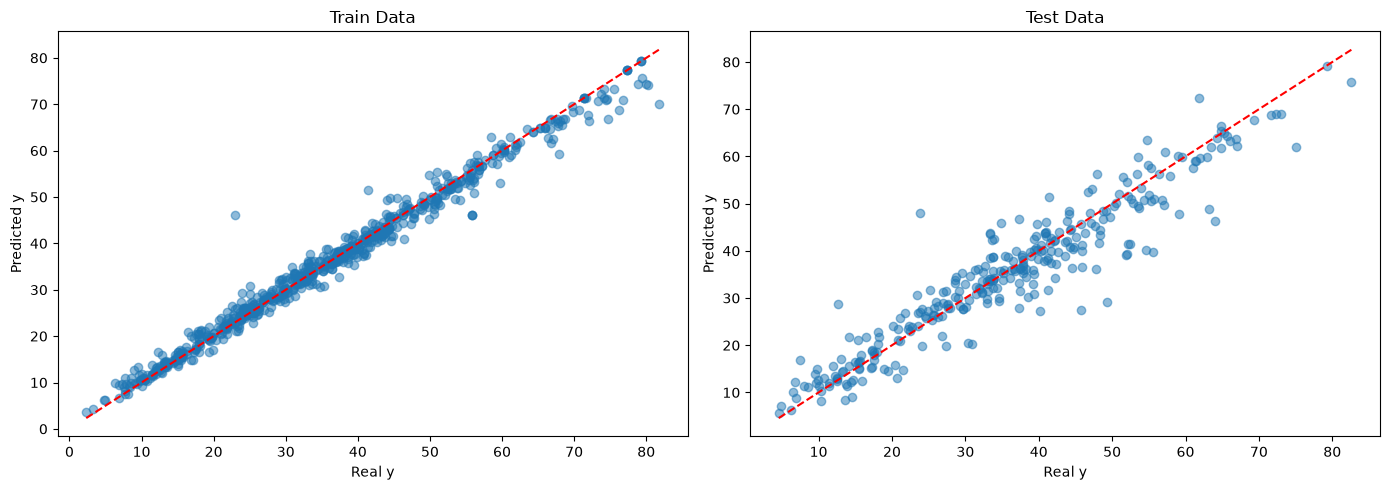

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  #서브플롯으로 뽑는게 시인성이 좋다.

axes[0].scatter(Y_train_reg, RF_reg.predict(X_train_reg), alpha=0.5)
axes[0].plot([Y_train_reg.min(), Y_train_reg.max()], [Y_train_reg.min(), Y_train_reg.max()], "r--")
axes[0].set_xlabel("Real y"); axes[0].set_ylabel("Predicted y"); axes[0].set_title("Train Data")

axes[1].scatter(Y_test_reg, RF_reg_pred, alpha=0.5)
axes[1].plot([Y_test_reg.min(), Y_test_reg.max()], [Y_test_reg.min(), Y_test_reg.max()], "r--")
axes[1].set_xlabel("Real y"); axes[1].set_ylabel("Predicted y"); axes[1].set_title("Test Data")

plt.tight_layout()
plt.show()

### 2-4) 모델 성능 개선

In [20]:
params_reg = {
    "max_depth": [5, 10, 15],
    "min_samples_leaf": [2, 4],
    "n_estimators": [100, 300]
}

grid_reg = GridSearchCV(
    RandomForestRegressor(random_state=0),
    param_grid=params_reg, cv=5, scoring="r2", n_jobs=-1
)
grid_reg.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_reg.best_params_)
print("최적 R-squared: %.4f" % grid_reg.best_score_)

최적 파라미터: {'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 300}
최적 R-squared: 0.8902


In [21]:
# 최적 모델로 테스트 성능 평가
best_pred_reg = grid_reg.predict(X_test_reg)
get_regscore(Y_test_reg, best_pred_reg)

MSE       : 28.230
RMSE      : 5.313
MAE       : 3.784
R-squared : 0.890


---

## 5) Vibe Coding 실습

**[과제 1]**
지수는 Random Forest가 계산한 변수 중요도(Feature Importance)가 정말 중요한 변수를 의미하는지 궁금해졌습니다. AI와 상의하여 변수 중요도를 확인하고, 중요도가 높은 상위 변수만 사용했을 때와 전체 변수를 사용했을 때의 성능을 비교해 보세요. 결과를 바탕으로 "중요한 변수만 사용하면 항상 좋은 모델이 될까?"에 대해 자신의 의견을 정리해 보세요.

중요한 변수만 사용하면 항상 좋은 모델이 될까?
#1. Random Forest의 결과를 통해 데이터의 변수 중요도를 확인해보자.

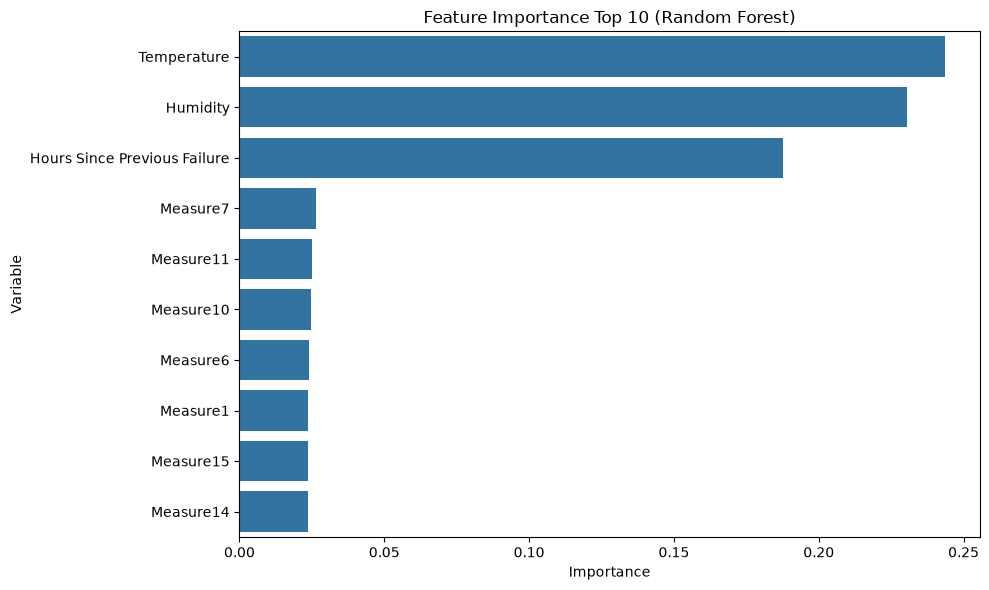

In [ ]:
# 변수 중요도 추출 및 시각화
var_imp = pd.DataFrame({"Variable": cls_columns, "Importance": RF_cls.feature_importances_})
imp_top10 = var_imp.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=imp_top10)
plt.title("Feature Importance Top 10 (Random Forest)")
plt.tight_layout()
plt.show()

# 'Temperature','Humidity','Hours Since Previous Failure' 이 3가지 변수가 특별히 중요하다.

#2. 중요한 변수만 사용해서 Random Forest를 다시 수행해보자.

In [24]:
# 'Temperature','Humidity','Hours Since Previous Failure' 이 3가지 변수만 써서 분석하기
# 입출력 변수 분할
Y_cls = MF_Data["Failure"]
X_cls = MF_Data.drop(["Failure"], axis=1)

# 범주형 변수 처리
X_cls["Measure2"] = X_cls["Measure2"].astype("category")
X_cls["Measure3"] = X_cls["Measure3"].astype("category")
X_cls = pd.get_dummies(X_cls)
cls_columns = X_cls.columns

# 출력변수 인코딩
Y_cls = Y_cls.replace({"No": 0, "Yes": 1}).astype(int)

# 데이터 분할 (전체 변수)
X_train_cls, X_test_cls, Y_train_cls, Y_test_cls = train_test_split(
    X_cls, Y_cls, test_size=0.3, random_state=0, stratify=Y_cls)

print("학습 데이터 :", X_train_cls.shape)
print("테스트 데이터 :", X_test_cls.shape)

# ── X_cls_2: 중요 변수 3개만 사용 ──────────────────────────────
important_cols = ["Temperature", "Humidity", "Hours Since Previous Failure"]
X_cls_2 = MF_Data[important_cols]

X_train_cls_2, X_test_cls_2, Y_train_cls_2, Y_test_cls_2 = train_test_split(
    X_cls_2, Y_cls, test_size=0.3, random_state=0, stratify=Y_cls)

print("\n[X_cls_2 — important features only]")
print("학습 데이터 :", X_train_cls_2.shape)
print("테스트 데이터 :", X_test_cls_2.shape)
print("사용 변수 :", list(X_cls_2.columns))

학습 데이터 : (5530, 31)
테스트 데이터 : (2370, 31)

[X_cls_2 — important features only]
학습 데이터 : (5530, 3)
테스트 데이터 : (2370, 3)
사용 변수 : ['Temperature', 'Humidity', 'Hours Since Previous Failure']


In [ ]:
RF_cls = RandomForestClassifier()
RF_cls.fit(X_train_cls_2, Y_train_cls)
RF_cls_pred = RF_cls.predict(X_test_cls_2)
get_classscore(Y_test_cls, RF_cls_pred)

Accuracy  : 0.997
Precision : 0.941
Recall    : 0.727
F1-score  : 0.821

혼동행렬
[[2347    1]
 [   6   16]]


# 모든 변수를 썼을 때의 F1-score보다 주요 변수를 썼을때 좀더 개선되었다!
Accuracy  : 0.997
Precision : 1.000
Recall    : 0.682
**F1-score  : 0.811**

혼동행렬
[[2348    0]
 [   7   15]]

[조교의 프롬프트]

회귀 데이터셋과 분류 데이터셋에 대해 Random Forest 모델 결과를 도출했었어.
주요하다고 나타난 변수들 몇개만 가지고 학습해도 성능이 비슷한지 궁금한데

1. 주요하다고 판단할만한 수치를 말해주고
2. 해당 수치 기반으로 했을 때 각 데이터셋에서 유의미한 변수만 남기는 코드를 주고
3. 새로운 Random Forest 모델을 학습하고 예측하는 코드 주고
4. 모든 변수를 학습했던 것과

**[과제 2]** 지수는 Random Forest가 단일 의사결정나무보다 항상 더 좋은 성능을 보이는지 궁금해졌습니다. 동일한 데이터로 단일 의사결정나무 모델을 학습시켜 이번 실습의 Random Forest 모델과 성능을 비교해 보세요. 그리고 그 차이가 나타나는 이유를 AI와 상의하여 해석해 보세요.

[조교의 프롬프트]
Random Forest가 다양한 의사결정나무를 가지고 학습하다보니 단일 트리보다 유리한지가 궁금해

1. 회귀 데이터셋으로 Random Forest 모델 학습한거랑 단일 의사결정 나무로 학습한것을 비교하는 코드 짜줘.
1. 분류 데이터셋으로 Random Forest 모델 학습한거랑 단일 의사결정 나무로 학습한것을 비교하는 코드 짜줘.

In [36]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

# ── 1) 회귀: Random Forest vs 단일 Decision Tree ─────────────────
reg_models = {
    "Random Forest": RandomForestRegressor(random_state=0),
    "Decision Tree": DecisionTreeRegressor(random_state=0),
}

reg_rows = []
for name, model in reg_models.items():
    model.fit(X_train_reg, Y_train_reg)
    pred = model.predict(X_test_reg)
    reg_rows.append({
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(Y_test_reg, pred)),
        "MAE": mean_absolute_error(Y_test_reg, pred),
        "R-squared": r2_score(Y_test_reg, pred),
    })

reg_compare = pd.DataFrame(reg_rows).set_index("Model").round(3)
print("=== Regression Comparison ===")
print(reg_compare.head())

# ── 2) 분류: Random Forest vs 단일 Decision Tree ─────────────────
cls_models = {
    "Random Forest": RandomForestClassifier(random_state=0),
    "Decision Tree": DecisionTreeClassifier(random_state=0),
}

cls_rows = []
for name, model in cls_models.items():
    model.fit(X_train_cls, Y_train_cls)
    pred = model.predict(X_test_cls)
    cls_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(Y_test_cls, pred),
        "Precision": precision_score(Y_test_cls, pred, zero_division=0),
        "Recall": recall_score(Y_test_cls, pred, zero_division=0),
        "F1": f1_score(Y_test_cls, pred, zero_division=0),
    })

cls_compare = pd.DataFrame(cls_rows).set_index("Model").round(3)
print()
print("=== Classification Comparison ===")
print(cls_compare.head())

=== Regression Comparison ===
                RMSE    MAE  R-squared
Model                                 
Random Forest  5.175  3.591      0.896
Decision Tree  7.624  4.860      0.774

=== Classification Comparison ===
               Accuracy  Precision  Recall     F1
Model                                            
Random Forest     0.997      1.000   0.682  0.811
Decision Tree     0.994      0.667   0.727  0.696


# Random Forest가 더 우수하게 나온 결과에 대한 AI의 해석
회귀에서는 RF가 RMSE가 더 낮고 R²가 더 높아, 단일 트리보다 예측 오차가 작고 일반화가 잘 되었다. 분류에서는 Accuracy는 비슷하지만 RF의 Precision과 F1이 더 높아, 고장 예측 시 헛경보를 줄이면서 전체적으로 더 균형 잡힌 성능을 보였다. 이는 RF가 여러 트리의 예측을 결합해 분산을 줄이고 과적합을 완화하기 때문이다.

**[과제 3]** 지수는 Random Forest의 성능을 더 높이기 위해 하이퍼파라미터 튜닝을 시도하려고 합니다. 하지만 n_estimators, max_depth, min_samples_split, max_features 등의 의미와 적절한 범위를 잘 모릅니다. AI와 상의하여 각 하이퍼파라미터의 역할을 이해하고 탐색 범위를 직접 설정해 보세요. 이후 GridSearchCV를 활용해 최적의 조합을 찾고, 왜 해당 조합이 선택되었는지 결과를 해석해 보세요.

[프롬프트]

Random Forest의 성능을 더 높이기 위해 하이퍼파라미터 튜닝을 시도하려고 해. 하지만 n_estimators, max_depth, min_samples_split, max_features 등의 의미와 적절한 범위를 잘 몰라.

1. 각 하이퍼파라미터의 역할을 알려줘.
2. 탐색 범위를 추천해줘.
3. GridSearchCV를 활용해 최적의 조합을 찾아줘.
4. 결과를 알려줄테니 왜 해당 조합이 선택되었는지 결과를 해석해 줘.

In [ ]:
# 과제 3) Random Forest 하이퍼파라미터 튜닝 (GridSearchCV)
# ── 하이퍼파라미터 역할 ──────────────────────────────────────────
# n_estimators      : 트리 개수 (많을수록 안정적, 학습 시간 증가)
# max_depth         : 트리 최대 깊이 (작을수록 단순·과적합 감소)
# min_samples_split : 노드를 분할하기 위한 최소 샘플 수 (클수록 단순화)
# max_features      : 각 분할 시 고려할 변수 수 (다양성↑, 과적합 감소)

# ── 탐색 범위 (과제용 추천) ─────────────────────────────────────
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"],
}

# 1) 분류 (불균형 → F1 기준)
grid_cls_hw3 = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)
grid_cls_hw3.fit(X_train_cls, Y_train_cls)

print("=== Classification GridSearch ===")
print("Best params :", grid_cls_hw3.best_params_)
print("Best CV F1  :", round(grid_cls_hw3.best_score_, 4))

best_cls_pred = grid_cls_hw3.predict(X_test_cls)
get_classscore(Y_test_cls, best_cls_pred)

# 2) 회귀 (R² 기준)
grid_reg_hw3 = GridSearchCV(
    RandomForestRegressor(random_state=0),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
grid_reg_hw3.fit(X_train_reg, Y_train_reg)

print()
print("=== Regression GridSearch ===")
print("Best params :", grid_reg_hw3.best_params_)
print("Best CV R2  :", round(grid_reg_hw3.best_score_, 4))

best_reg_pred = grid_reg_hw3.predict(X_test_reg)
get_regscore(Y_test_reg, best_reg_pred)

# 상위 5개 조합 확인 (해석용)
cv_cls = pd.DataFrame(grid_cls_hw3.cv_results_).sort_values("rank_test_score")
cv_reg = pd.DataFrame(grid_reg_hw3.cv_results_).sort_values("rank_test_score")

print()
print("Top 5 — Classification")
display(cv_cls[["params", "mean_test_score", "std_test_score"]].head(5))

print("Top 5 — Regression")
display(cv_reg[["params", "mean_test_score", "std_test_score"]].head(5))

=== Classification GridSearch ===
Best params : {'max_depth': 15, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 300}
Best CV F1  : 0.8071
Accuracy  : 0.997
Precision : 1.000
Recall    : 0.682
F1-score  : 0.811

혼동행렬
[[2348    0]
 [   7   15]]

=== Regression GridSearch ===
Best params : {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 100}
Best CV R2  : 0.8967
MSE       : 26.678
RMSE      : 5.165
MAE       : 3.682
R-squared : 0.896

Top 5 — Classification


,params,mean_test_score,std_test_score
50,"{'max_depth': 15, 'max_features': 'log2', 'min...",0.807104,0.036989
68,"{'max_depth': None, 'max_features': 'log2', 'm...",0.807104,0.036989
18,"{'max_depth': 10, 'max_features': 'sqrt', 'min...",0.800757,0.038367
39,"{'max_depth': 15, 'max_features': 'sqrt', 'min...",0.797348,0.024565
57,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.797348,0.024565


Top 5 — Regression


,params,mean_test_score,std_test_score
63,"{'max_depth': None, 'max_features': 'log2', 'm...",0.896724,0.007864
45,"{'max_depth': 15, 'max_features': 'log2', 'min...",0.896309,0.008950
47,"{'max_depth': 15, 'max_features': 'log2', 'min...",0.895980,0.008307
64,"{'max_depth': None, 'max_features': 'log2', 'm...",0.895831,0.007381
65,"{'max_depth': None, 'max_features': 'log2', 'm...",0.895134,0.007587


: 

**[과제 4]**
지수는 Random Forest에서 나무의 개수(n_estimators)를 많이 늘릴수록 성능이 계속 좋아지는지 궁금해졌습니다. AI와 상의하여 다양한 n_estimators 값(예: 10, 50, 100, 200, 500 등)으로 모델을 학습시키고 성능 변화를 그래프로 시각화해 보세요. 성능 향상과 학습 시간의 변화를 함께 확인한 뒤, 실무에서는 어떤 값을 선택하는 것이 적절할지 의견을 정리해 보세요.